In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [70]:
df = pd.read_csv("season-2425.csv")
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,2024-08-16,Man United,Fulham,1,0,H,0,0,D,R Jones,...,5,2,12,10,7,8,2,3,0,0
1,2024-08-17,Ipswich,Liverpool,0,2,A,0,0,D,T Robinson,...,2,5,9,18,2,10,3,1,0,0
2,2024-08-17,Arsenal,Wolves,2,0,H,1,0,H,J Gillett,...,6,3,17,14,8,2,2,2,0,0
3,2024-08-17,Everton,Brighton,0,3,A,0,1,A,S Hooper,...,1,5,8,8,1,5,1,1,1,0
4,2024-08-17,Newcastle,Southampton,1,0,H,1,0,H,C Pawson,...,1,4,15,16,3,12,2,4,1,0


### Vill få fram ett diagram på hur tabellen såg ut efter första halvan av säsongen, vilket lag hade flest poäng?

In [80]:
df["Date"] = pd.to_datetime(df["Date"]) #Konvertera till datumobjekt med pandas


In [81]:
df["HomePoints"] = np.where(df["FTR"] == "H", 3, np.where(df["FTR"] == "D", 1, 0)) #om hemmalaget vann 3 poäng, om oavgjort 1 poäng, annars 0

In [82]:
df["Awaypoints"] = np.where(df["FTR"]  == "A",  3, np.where(df["FTR"] == "D", 1,  0)) #likadan som ovanstående fast för bortalag

In [83]:
first_half = df[df["Date"] < "2025-01-01"] #Filtrerar så jag får datum innan 2025-01-01

In [84]:
home = first_half.groupby("HomeTeam")["HomePoints"].sum()

In [85]:
away = first_half.groupby("AwayTeam")["Awaypoints"].sum()


In [86]:
total_points = home.add(away, fill_value=0)

In [87]:
total_points.sort_values(ascending=False)


HomeTeam
Liverpool         45
Nott'm Forest     37
Arsenal           36
Chelsea           35
Newcastle         32
Man City          31
Bournemouth       30
Fulham            29
Aston Villa       29
Brighton          27
Tottenham         24
Brentford         24
West Ham          23
Man United        22
Crystal Palace    20
Everton           17
Wolves            16
Ipswich           15
Leicester         14
Southampton        6
dtype: int64

# Liverpool leder ligan med 45 poäng och bottentippade Nottingham ligger 2a!

Text(0, 0.5, 'Poäng')

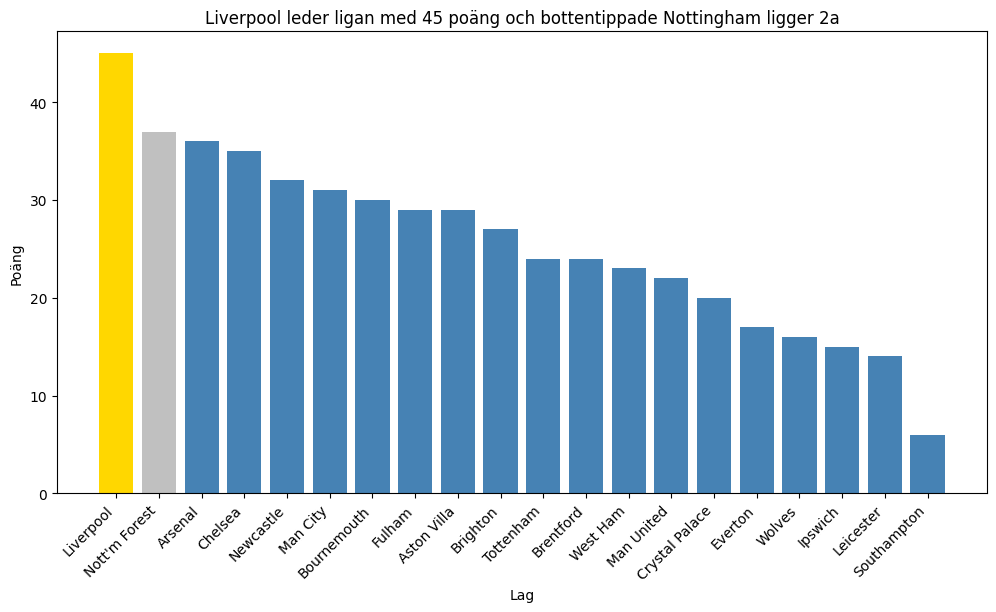

In [101]:
total_points = total_points.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
plt.xticks(rotation=45, ha="right")
colors = ["gold" if i == 0 else "silver" if i == 1 else "steelblue" for i in range(len(total_points))]
ax.bar(total_points.index, total_points.values, color=colors)
ax.set_title("Liverpool leder ligan med 45 poäng och bottentippade Nottingham ligger 2a")
ax.set_xlabel("Lag")
ax.set_ylabel("Poäng")

In [115]:
df["TotalYellow"] = df["HY"] + df["AY"]
df["TotalRed"] = df["HR"] + df["AR"]
yellow_cards = df.groupby("Referee")["TotalYellow"].sum().sort_values(ascending=False)
yellow_cards

Referee
S Hooper        108
M Oliver        108
S Barrott       106
C Kavanagh       96
C Pawson         94
R Jones          93
A Taylor         88
A Madley         86
J Brooks         86
P Bankes         85
D England        79
S Attwell        72
T Harrington     72
J Gillett        68
T Robinson       68
D Bond           55
M Salisbury      43
T Bramall        36
D Coote          30
L Smith          26
J Smith          13
S Allison         8
D Webb            7
O Oliver          5
A Kitchen         4
K Kavanagh        3
Name: TotalYellow, dtype: int64

In [114]:
red_cards = df.groupby("Referee")["TotalRed"].sum().sort_values(ascending=False)
red_cards

Referee
A Taylor        6
M Oliver        5
C Kavanagh      5
T Bramall       4
D England       4
R Jones         4
C Pawson        3
T Harrington    3
S Attwell       3
P Bankes        3
M Salisbury     3
T Robinson      2
S Hooper        2
S Barrott       1
L Smith         1
A Madley        1
J Brooks        1
D Bond          1
O Oliver        0
K Kavanagh      0
J Smith         0
S Allison       0
J Gillett       0
D Webb          0
D Coote         0
A Kitchen       0
Name: TotalRed, dtype: int64

In [119]:
total_cards = yellow_cards.add(red_cards, fill_value=0)
top15 = total_cards.sort_values(ascending=False).head(15)
yellow_top15 = yellow_cards[top15.index]
red_top15 = red_cards[top15.index]
yellow_top15


Referee
M Oliver        108
S Hooper        108
S Barrott       106
C Kavanagh       96
R Jones          93
C Pawson         94
A Taylor         88
P Bankes         85
A Madley         86
J Brooks         86
D England        79
S Attwell        72
T Harrington     72
T Robinson       68
J Gillett        68
Name: TotalYellow, dtype: int64

Text(0.5, 1.0, 'M. Oliver toppar listan på gula kort')

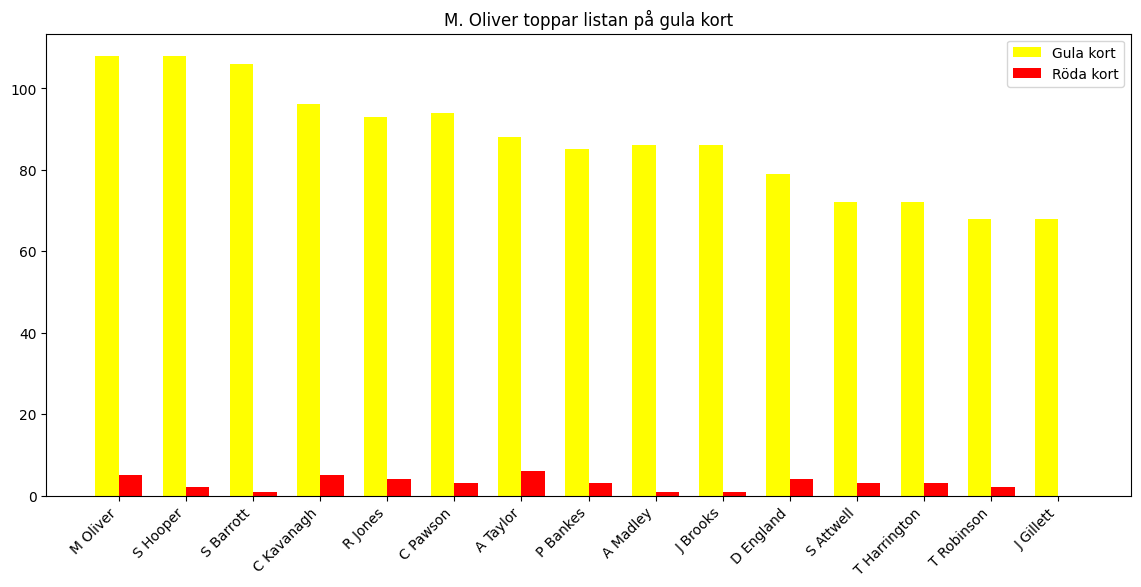

In [121]:
x = np.arange(len(top15.index))  # positioner på x-axeln
width = 0.35  # bredden på varje stapel

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, yellow_top15.values, width, color="yellow", label="Gula kort")
ax.bar(x + width/2, red_top15.values, width, color="red", label="Röda kort")

ax.set_xticks(x)
ax.set_xticklabels(top15.index, rotation=45, ha="right")
ax.legend()
ax.set_title("M. Oliver toppar listan på gula kort")
